# Task 2 — Text Chunking, Embedding, and Vector Store Indexing

**Goal:** Build the end-to-end pipeline that converts cleaned complaint narratives
into a searchable semantic vector store.


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    FILTERED_DATA_PATH, SAMPLE_SIZE, RANDOM_SEED,
    CHUNK_SIZE, CHUNK_OVERLAP, EMBEDDING_MODEL_NAME,
    CHROMA_COLLECTION_NAME, VECTOR_STORE_DIR,
)
from src.sampling import stratified_sample
from src.chunking import chunk_dataframe
from src.embeddings import embed_texts
from src.vector_store import build_and_persist_vector_store, load_vector_store
from src.utils import save_figure

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 1. Load Filtered Dataset

Load the output of Task 1 (`filtered_complaints.csv`).

In [2]:
df = pd.read_csv(FILTERED_DATA_PATH, dtype={"complaint_id": str})
print(f"Loaded {len(df):,} rows from {FILTERED_DATA_PATH}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Loaded 469,999 rows from C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\filtered_complaints.csv
Columns: ['complaint_id', 'product_category', 'issue', 'sub_issue', 'company', 'state', 'date_received', 'cleaned_narrative', 'narrative_word_count']


,complaint_id,product_category,issue,sub_issue,company,state,date_received,cleaned_narrative,narrative_word_count
0,14069121,Credit Card,Getting a credit card,Card opened without my consent or knowledge,"CITIBANK, N.A.",TX,2025-06-13,a redacted redacted card was opened under my n...,91
1,14061897,Savings Account,Managing an account,Deposits and withdrawals,WELLS FARGO & COMPANY,ID,2025-06-13,i made the mistake of using my wellsfargo debi...,109
2,14047085,Credit Card,"Other features, terms, or problems",Other problem,"CITIBANK, N.A.",NY,2025-06-12,i have a secured credit card with citibank whi...,156


## 2. Stratified Sampling

Draw a **10,000-complaint stratified sample** with proportional representation
across all four product categories.

**Sampling strategy:**
- Proportion per category matches its share in the full filtered dataset.
- Fixed `random_state=42` for reproducibility.
- Sample size = 10,000 (centred in the 10K–15K rubric range; small enough to
  embed on standard hardware in under 15 minutes).


In [3]:
df_sample = stratified_sample(df, sample_size=SAMPLE_SIZE, seed=RANDOM_SEED)

print(f"=== Stratified Sample ===")
print(f"Total records: {len(df_sample):,}")
print()
dist = df_sample["product_category"].value_counts()
dist_pct = (dist / len(df_sample) * 100).round(1)
summary = pd.DataFrame({"Count": dist, "Percentage": dist_pct})
print(summary.to_string())

=== Stratified Sample ===
Total records: 10,000

                  Count  Percentage
product_category                   
Credit Card        4194        41.9
Savings Account    3302        33.0
Money Transfer     2100        21.0
Personal Loan       404         4.0


Figure saved → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\data\processed\figures\05_sample_distribution.png


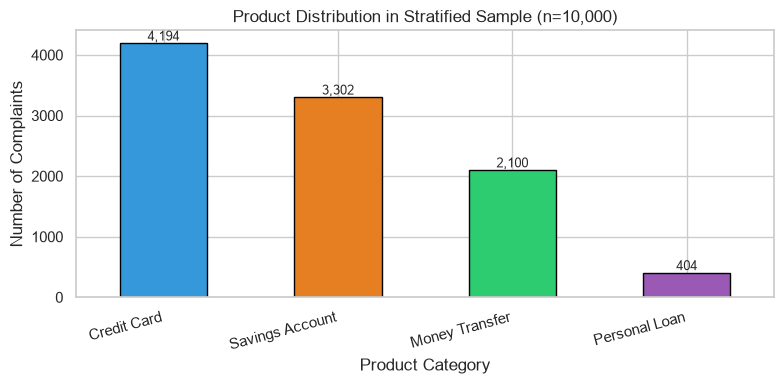

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
dist.plot(kind="bar", ax=ax, color=["#3498db","#e67e22","#2ecc71","#9b59b6"],
          edgecolor="black")
ax.set_title(f"Product Distribution in Stratified Sample (n={len(df_sample):,})")
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Complaints")
ax.set_xticklabels(dist.index, rotation=15, ha="right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save_figure("05_sample_distribution.png")
plt.show()

## 3. Text Chunking

Split each complaint narrative into overlapping character-level chunks.

**Configuration:**
- `chunk_size = 500` characters — roughly 80–100 words per chunk; stays within most
  embedding model context windows and preserves local context within a complaint.
- `chunk_overlap = 50` characters — 10% overlap prevents important information
  from being severed at a hard boundary without producing excessive redundancy.


In [5]:
print(f"Chunking config: chunk_size={CHUNK_SIZE}, chunk_overlap={CHUNK_OVERLAP}")
print("Running chunking pipeline...")

df_chunks = chunk_dataframe(
    df_sample,
    text_col="cleaned_narrative",
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
)

print(f"\n=== Chunking Results ===")
print(f"Input complaints : {len(df_sample):,}")
print(f"Total chunks     : {len(df_chunks):,}")
print(f"Avg chunks/complaint: {len(df_chunks) / len(df_sample):.1f}")

print("\n=== Sample Chunk Rows (first 5) ===")
print(df_chunks[["complaint_id", "product_category", "chunk_index",
                  "total_chunks", "chunk_text"]].head(5).to_string())

Chunking config: chunk_size=500, chunk_overlap=50
Running chunking pipeline...

=== Chunking Results ===
Input complaints : 10,000
Total chunks     : 30,469
Avg chunks/complaint: 3.0

=== Sample Chunk Rows (first 5) ===
  complaint_id product_category  chunk_index  total_chunks                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            chunk_text
0      3272302      Credit Card            0             5  first phone call i called to confirm promo and what credit bureau is used since my credit is frozen they answered my question. the promo he had said it is in a

In [6]:
# Distribution of chunks per complaint
chunks_per_complaint = df_chunks.groupby("complaint_id")["chunk_index"].max() + 1
print("=== Chunks per Complaint ===")
print(chunks_per_complaint.describe().round(1).to_string())

=== Chunks per Complaint ===
count    10000.0
mean         3.0
std          2.9
min          1.0
25%          1.0
50%          2.0
75%          4.0
max         83.0


## 4. Embedding Generation

Encode all chunk texts using `sentence-transformers/all-MiniLM-L6-v2`.

**Why this model:**
- 384-dimensional embeddings — compact and fast.
- Trained on large-scale sentence-pair data; strong semantic similarity performance.
- ~80 MB download; CPU-compatible with reasonable throughput (~1,500 sentences/min).
- Matches the model used in the pre-built full-dataset vector store (Tasks 3–4),
  so query embeddings are compatible.


In [7]:
import time

texts = df_chunks["chunk_text"].tolist()
print(f"Embedding {len(texts):,} chunks using {EMBEDDING_MODEL_NAME}...")

start = time.time()
embeddings = embed_texts(texts, batch_size=64, show_progress=True)
elapsed = time.time() - start

print(f"\n=== Embedding Results ===")
print(f"Embedding shape : {embeddings.shape}")
print(f"Time taken      : {elapsed:.1f}s  ({elapsed/60:.1f} min)")
print(f"Dtype           : {embeddings.dtype}")

Embedding 30,469 chunks using sentence-transformers/all-MiniLM-L6-v2...
Loading embedding model: sentence-transformers/all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.


Batches:   0%|          | 0/477 [00:00<?, ?it/s]


=== Embedding Results ===
Embedding shape : (30469, 384)
Time taken      : 1759.5s  (29.3 min)
Dtype           : float32


## 5. Build and Persist Vector Store

Index all chunk embeddings into a ChromaDB collection and persist to `vector_store/`.


In [8]:
collection = build_and_persist_vector_store(
    chunks_df=df_chunks,
    embeddings=embeddings,
    collection_name=CHROMA_COLLECTION_NAME,
    batch_size=500,
)

  Indexed 30,469/30,469 chunks...
✓ Vector store persisted → C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\vector_store
  Collection 'complaint_chunks' — 30,469 chunks total.


## 6. Verification

Reload the vector store from disk and run a test query to confirm everything works.


In [9]:
# Reload from disk (simulates what Task 3 will do)
collection_reloaded = load_vector_store(CHROMA_COLLECTION_NAME)
print(f"✓ Collection reloaded — {collection_reloaded.count():,} chunks indexed")
print(f"  Stored at: {VECTOR_STORE_DIR}")

✓ Collection reloaded — 30,469 chunks indexed
  Stored at: C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\vector_store


In [10]:
from src.embeddings import embed_texts

test_query = "Why are customers unhappy with their credit cards?"
query_emb = embed_texts([test_query], show_progress=False)

results = collection_reloaded.query(
    query_embeddings=query_emb.tolist(),
    n_results=3,
    include=["documents", "metadatas", "distances"],
)

print(f"=== Test Query: '{test_query}' ===\n")
for i, (doc, meta, dist) in enumerate(zip(
    results["documents"][0],
    results["metadatas"][0],
    results["distances"][0],
), 1):
    print(f"Result {i} | product: {meta['product_category']} | "
          f"complaint_id: {meta['complaint_id']} | distance: {dist:.4f}")
    print(f"  Chunk: {doc[:200]}...")
    print()

=== Test Query: 'Why are customers unhappy with their credit cards?' ===

Result 1 | product: Credit Card | complaint_id: 3856544 | distance: 0.2882
  Chunk: h customers during these difficult time??? that is not our fault? credit card companies need to do what the government asked them to do help consumers during these difficult times....

Result 2 | product: Credit Card | complaint_id: 5718116 | distance: 0.3030
  Chunk: ounts are being assessed fees and credit bureaus being contacted? why can customers not use any of their credit cards?...

Result 3 | product: Credit Card | complaint_id: 13020574 | distance: 0.3237
  Chunk: less about faithful customers, they only care about customers that they can redacted with high interest rates and take advantage of them. if age is an issue we need to know why. we had to replace our ...



In [12]:
print("=== Task 2 Summary ===")
print(f"Sample size         : {len(df_sample):,} complaints")
print(f"Chunk size          : {CHUNK_SIZE} chars")
print(f"Chunk overlap       : {CHUNK_OVERLAP} chars")
print(f"Total chunks        : {len(df_chunks):,}")
print(f"Embedding model     : {EMBEDDING_MODEL_NAME}")
print(f"Embedding dimensions: {embeddings.shape[1]}")
print(f"Vector store path   : {VECTOR_STORE_DIR}")
print(f"Collection name     : {CHROMA_COLLECTION_NAME}")

=== Task 2 Summary ===
Sample size         : 10,000 complaints
Chunk size          : 500 chars
Chunk overlap       : 50 chars
Total chunks        : 30,469
Embedding model     : sentence-transformers/all-MiniLM-L6-v2
Embedding dimensions: 384
Vector store path   : C:\Users\gtta1\OneDrive\Documents\KAIM\w7\rag-complaint-chatbot\vector_store
Collection name     : complaint_chunks
